# import needded columns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,accuracy_score,confusion_matrix,classification_report,silhouette_score

from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,AdaBoostRegressor,VotingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.cluster import KMeans,DBSCAN


from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger,ModelCheckpoint

## **Data Representation**

In [3]:
df = pd.read_csv('D:\\PROJECTS\\PROJECT 16\\Zara_sales_EDA.csv', sep=';')
df

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20247,219627,Front of Store,Yes,clothing,No,1754,Zara,https://www.zara.com/us/en/suit-jacket-in-100-...,CROPPED WASHED T-SHIRT CHARCOAL,Running shoes. Upper in a combination of piece...,31.95,USD,jeans,WOMAN,Summer,Linen Blend,India
20248,219628,Aisle,No,clothing,No,872,Zara,https://www.zara.com/us/en/fleece-overshirt-p0...,SATIN WOVEN LEATHER SLIDES STONE,Slim fit shirt. Round neck and short sleeves.,49.99,USD,jackets,WOMAN,Spring,Linen,China
20249,219629,Aisle,Yes,clothing,No,1360,Zara,https://www.zara.com/us/en/faux-suede-patch-ja...,RELAXED CROPPED LEATHER JACKET CHARCOAL,Ankle boots. Made of leather with a suede fini...,20.99,USD,shoes,WOMAN,Spring,Polyester,China
20250,219630,Aisle,No,clothing,No,892,Zara,https://www.zara.com/us/en/fine-knit-crop-swea...,SLIM BASIC 100% WOOL SWEATER BURGUNDY,RETRO SNEAKERS,64.95,USD,jackets,WOMAN,Winter,Polyester,Spain


In [4]:
df.sample()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
8099,207479,Front of Store,No,clothing,Yes,834,Zara,https://www.zara.com/us/en/moc-toe-suede-boots...,FAUX LEATHER PUFFER JACKET KHAKI,Varsity jacket with elastic collar and long sl...,55.99,USD,jackets,WOMAN,Winter,Wool,China


In [5]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [6]:
df.describe()

,Product ID,Sales Volume,price
count,20252.000000,20252.000000,20252.000000
mean,208931.432303,1097.400454,41.949061
std,8961.076507,298.234609,23.380960
min,110075.000000,518.000000,12.000000
25%,204442.750000,849.000000,23.950000
50%,209505.500000,990.000000,35.950000
75%,214568.250000,1364.250000,53.950000
max,219631.000000,1940.000000,134.990000


In [7]:
df.value_counts()

Product ID  Product Position  Promotion  Product Category  Seasonal  Sales Volume  brand  url                                                                                      name                                           description                                                                                                                                                                                                                   price  currency  terms     section  season  material     origin  
219631      Aisle             No         clothing          No        859           Zara   https://www.zara.com/us/en/contrasting-patches-hooded-jacket-p03833400.html              KNIT TUXEDO JACKET BURGUNDY                    Relaxed fit overshirt made of linen fabric. Lapel collar and long sleeves with buttoned cuffs. Chest patch pockets. Front button closure.                                                                                     64.99  USD       shoes     MAN      Su

In [8]:
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='object')

In [9]:
df.shape

(20252, 17)

In [10]:
df.index

RangeIndex(start=0, stop=20252, step=1)

In [11]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [12]:
df.tail()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
20247,219627,Front of Store,Yes,clothing,No,1754,Zara,https://www.zara.com/us/en/suit-jacket-in-100-...,CROPPED WASHED T-SHIRT CHARCOAL,Running shoes. Upper in a combination of piece...,31.95,USD,jeans,WOMAN,Summer,Linen Blend,India
20248,219628,Aisle,No,clothing,No,872,Zara,https://www.zara.com/us/en/fleece-overshirt-p0...,SATIN WOVEN LEATHER SLIDES STONE,Slim fit shirt. Round neck and short sleeves.,49.99,USD,jackets,WOMAN,Spring,Linen,China
20249,219629,Aisle,Yes,clothing,No,1360,Zara,https://www.zara.com/us/en/faux-suede-patch-ja...,RELAXED CROPPED LEATHER JACKET CHARCOAL,Ankle boots. Made of leather with a suede fini...,20.99,USD,shoes,WOMAN,Spring,Polyester,China
20250,219630,Aisle,No,clothing,No,892,Zara,https://www.zara.com/us/en/fine-knit-crop-swea...,SLIM BASIC 100% WOOL SWEATER BURGUNDY,RETRO SNEAKERS,64.95,USD,jackets,WOMAN,Winter,Polyester,Spain
20251,219631,Aisle,No,clothing,No,859,Zara,https://www.zara.com/us/en/contrasting-patches...,KNIT TUXEDO JACKET BURGUNDY,Relaxed fit overshirt made of linen fabric. La...,64.99,USD,shoes,MAN,Summer,Linen,Turkey


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  object 
 2   Promotion         20252 non-null  object 
 3   Product Category  20252 non-null  object 
 4   Seasonal          20252 non-null  object 
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

## **Data Wrangling**

**Missing Values**

In [14]:
df.isna().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                1
description         2
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [15]:
df.dropna(subset=['name', 'description'], inplace=True)


In [16]:
df.isna().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                0
description         0
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

**DUPLICATED Values**

In [17]:
df.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**


#### **Univariate Analysis**

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20250 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20250 non-null  int64  
 1   Product Position  20250 non-null  object 
 2   Promotion         20250 non-null  object 
 3   Product Category  20250 non-null  object 
 4   Seasonal          20250 non-null  object 
 5   Sales Volume      20250 non-null  int64  
 6   brand             20250 non-null  object 
 7   url               20250 non-null  object 
 8   name              20250 non-null  object 
 9   description       20250 non-null  object 
 10  price             20250 non-null  float64
 11  currency          20250 non-null  object 
 12  terms             20250 non-null  object 
 13  section           20250 non-null  object 
 14  season            20250 non-null  object 
 15  material          20250 non-null  object 
 16  origin            20250 non-null  object 
dty

In [19]:
df['origin'].value_counts()

origin
China         4026
Bangladesh    3617
Turkey        2475
India         2033
Morocco       1653
Portugal      1419
Spain         1248
Vietnam       1220
Cambodia       980
Brazil         795
Pakistan       605
Argentina      179
Name: count, dtype: int64

In [20]:
df['material'].value_counts()

material
Cotton         3850
Wool           3805
Wool Blend     3373
Polyester      2774
Linen          2573
Denim          1027
Viscose         990
Acrylic         881
Linen Blend     807
Satin           132
Silk             38
Name: count, dtype: int64

In [21]:
df['season'].value_counts()

season
Autumn    7664
Winter    5144
Spring    4536
Summer    2906
Name: count, dtype: int64

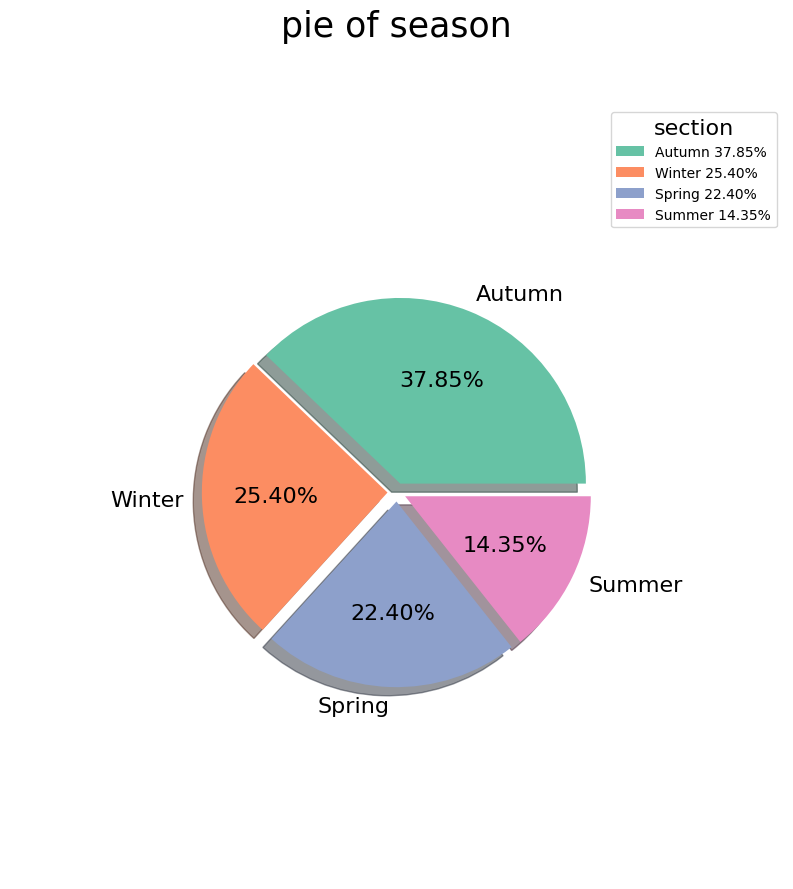

In [22]:
plt.figure(figsize=(18,9), facecolor="white")
season = df['season'].value_counts()
colors = sns.color_palette('Set2', n_colors=len(season))
plt.pie(df['season'].value_counts().values,labels=df['season'].value_counts().index,colors=colors,
                explode=[0.03]*4,autopct='%1.2f%%',shadow=True,radius=0.6,counterclock=True,textprops={'fontsize':16},
        frame=False,rotatelabels=False)
plt.title("pie of season", fontsize=25, pad=50)
plt.tight_layout()
plt.legend(loc='upper right',title='section',title_fontsize=16,labels=['Autumn 37.85%','Winter 25.40%','Spring 22.40%','Summer 14.35%'])
plt.show()

In [23]:
df['section'].value_counts()

section
WOMAN    13253
MAN       6997
Name: count, dtype: int64

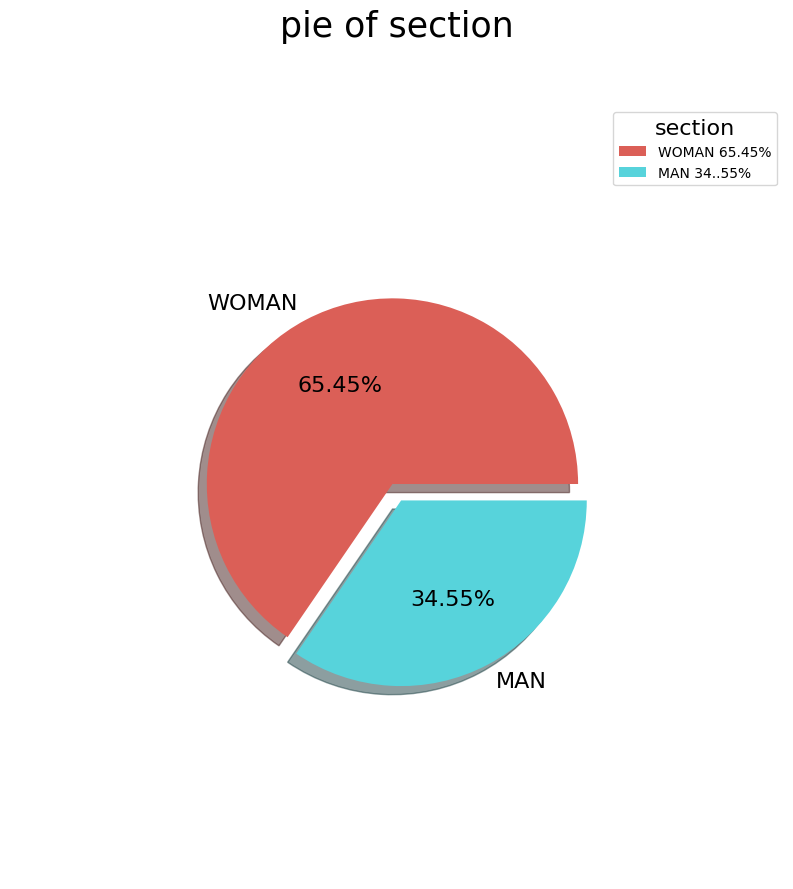

In [24]:
plt.figure(figsize=(18,9), facecolor="white")
section = df['section'].value_counts()
colors = sns.color_palette('hls', n_colors=len(section))
plt.pie(df['section'].value_counts().values,labels=df['section'].value_counts().index,colors=colors,
                explode=[0.03]*2,autopct='%1.2f%%',shadow=True,radius=0.6,counterclock=True,textprops={'fontsize':16},
        frame=False,rotatelabels=False)
plt.title("pie of section", fontsize=25, pad=50)
plt.tight_layout()
plt.legend(loc='upper right',title='section',title_fontsize=16,labels=['WOMAN 65.45%','MAN 34..55%'])
plt.show()

In [25]:
df['terms'].value_counts()

terms
jackets     11230
sweaters     3257
t-shirts     2646
shoes        2458
jeans         659
Name: count, dtype: int64

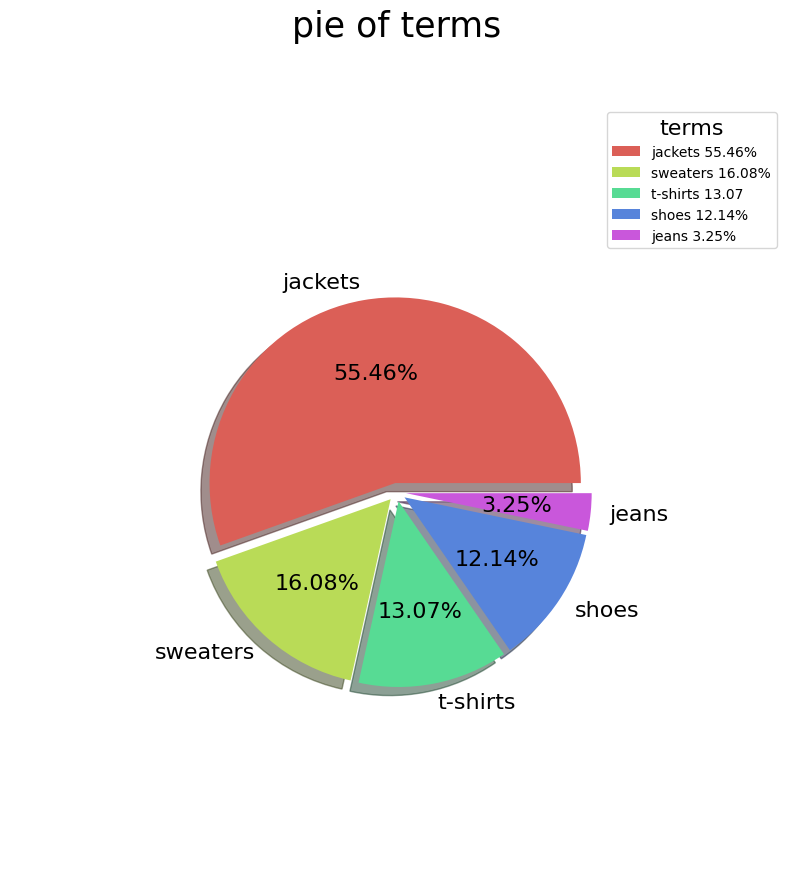

In [26]:
plt.figure(figsize=(18,9), facecolor="white")
terms = df['terms'].value_counts()
colors = sns.color_palette('hls', n_colors=len(terms))
plt.pie(df['terms'].value_counts().values,labels=df['terms'].value_counts().index,colors=colors,
                explode=[0.03]*5,autopct='%1.2f%%',shadow=True,radius=0.6,counterclock=True,textprops={'fontsize':16},
        frame=False,rotatelabels=False)
plt.title("pie of terms", fontsize=25, pad=50)
plt.tight_layout()
plt.legend(loc='upper right',title='terms',title_fontsize=16,labels=['jackets 55.46%','sweaters 16.08%','t-shirts 13.07','shoes 12.14%','jeans 3.25%'])
plt.show()

In [27]:
df['currency'].value_counts()

currency
USD    20250
Name: count, dtype: int64

In [28]:
df['price'].describe()

count    20250.000000
mean        41.950592
std         23.381581
min         12.000000
25%         23.950000
50%         35.950000
75%         53.950000
max        134.990000
Name: price, dtype: float64

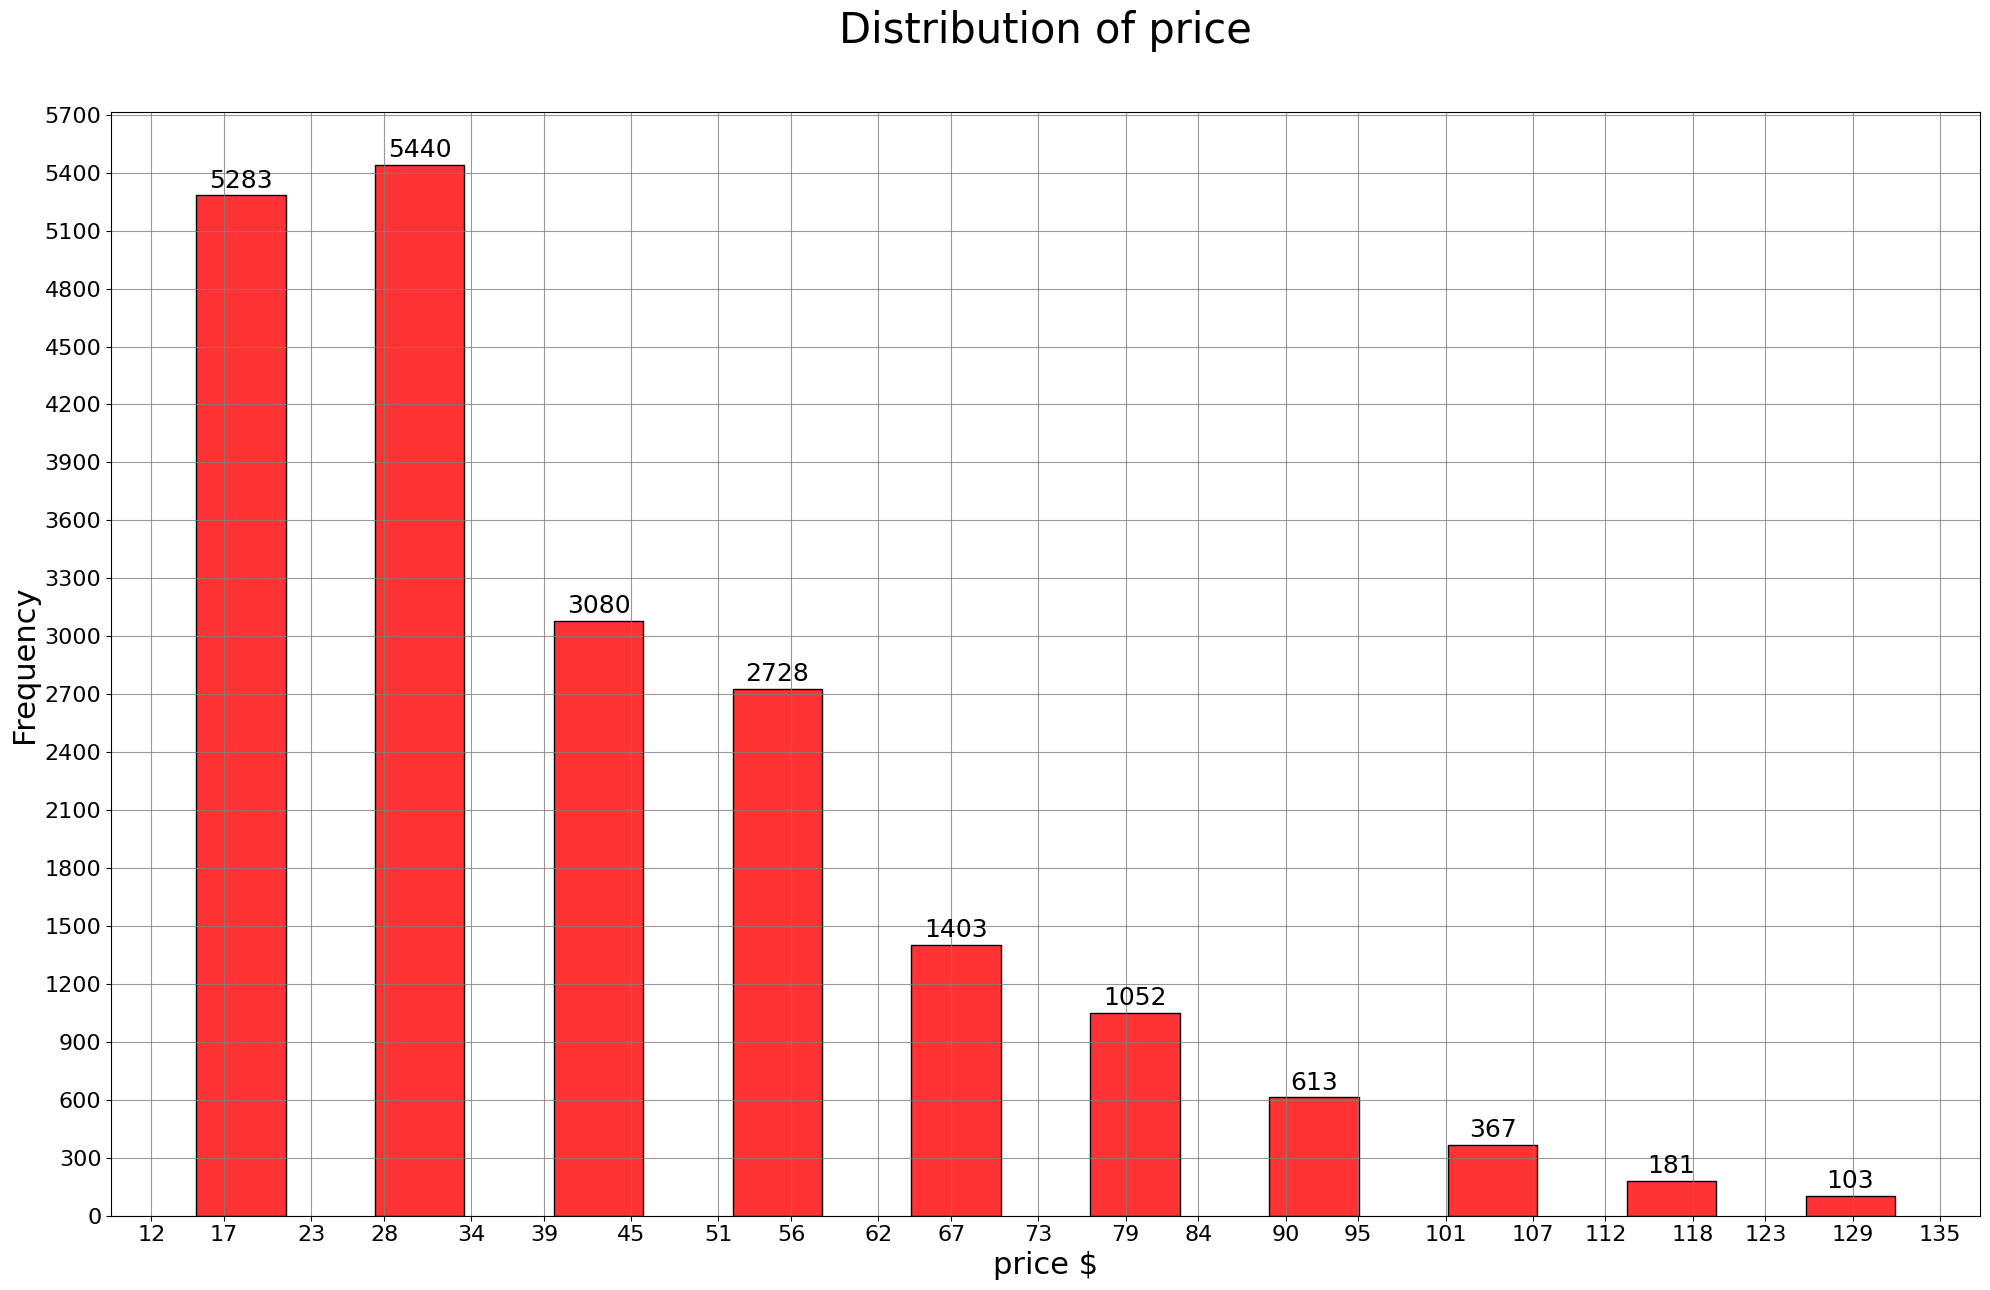

In [29]:
plt.figure(figsize=(20,13), facecolor="white")

ax=sns.histplot(df['price'], bins=10, edgecolor='black', alpha=0.8,color='red',shrink=0.5)

plt.title("Distribution of price", fontsize=30, pad=50)
plt.xlabel("price $", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.yticks(range(0,6000,300),fontsize=16)
plt.xticks(np.linspace(12, 135, 23, dtype=int), fontsize=16)

plt.grid(alpha=0.8,color='gray')

plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)
plt.show()

In [30]:
df['description'].value_counts()

description
Varsity jacket with elastic collar and long sleeves. Welt pockets at hip and interior pocket. Embroidered appliqué and contrast front and back patches. Rib trim. Front snap button closure.    333
Overshirt made of stretchy fabric. Lapel collar and long sleeves with snap buttoned cuffs. Chest patch pockets. Front snap button closure.                                                      197
Slightly cropped denim jacket. Lapel collar and long sleeves with buttoned cuffs. Flap patch pocket at chest and side hip. Washed effect. Front button closure.                                 179
Jacket made of technical fabric with padded interior. Tonal elastic rib high collar. Long sleeves. Welt pockets at hip and interior pocket. Interior elastic finish. Front zip closure.         178
Jacket with lightly padded interior. Corduroy lapel collar. Long sleeves. Patch pockets at hip. Front button closure.                                                                           177
        

In [31]:
df['name'].value_counts()

name
PLAID OVERSHIRT                                     8
PATCH BOMBER JACKET                                 5
SUIT JACKET IN 100% LINEN                           5
FAUX LEATHER JACKET                                 5
FAUX SUEDE BOMBER JACKET                            5
                                                   ..
SLIM HEART PRINT T-SHIRT ECRU                       1
REGULAR KNIT PEARL SWEATER BROWN                    1
KNIT ABSTRACT PRINT T-SHIRT SAND                    1
PAINT PRINT OVERSHIRT OLIVE                         1
DOUBLE-BREASTED CHUNKY SOLE HIGH TOP SNEAKERS #3    1
Name: count, Length: 17215, dtype: int64

In [32]:
df['url'].value_counts()

url
https://www.zara.com/us/en/knit-sweater-with-rips-p00021110.html                     187
https://www.zara.com/us/en/wool-blend-knit-sweater-p02893159.html                    185
https://www.zara.com/us/en/contrast-topstitching-crop-knit-sweater-p09598003.html    183
https://www.zara.com/us/en/hooded-technical-jacket-p01538301.html                    180
https://www.zara.com/us/en/basic-foil-knit-sweater-p00506101.html                    179
                                                                                    ... 
https://www.zara.com/us/en/suede-sneakers-p12502320.html                              64
https://www.zara.com/us/en/cotton---linen-blend-jacket-p00706103.html                 63
https://www.zara.com/us/en/knit-sweater-with-pearls-p02142249.html                    57
https://www.zara.com/us/en/pocket-overshirt-p00706621.html                            57
https://www.zara.com/us/en/hooded-knit-cardigan-p02621407.html                        55
Name: count, Leng

In [33]:
df['brand'].value_counts()

brand
Zara    20250
Name: count, dtype: int64

In [34]:
df['Sales Volume'].describe()

count    20250.000000
mean      1097.428148
std        298.236187
min        518.000000
25%        849.000000
50%        990.000000
75%       1364.750000
max       1940.000000
Name: Sales Volume, dtype: float64

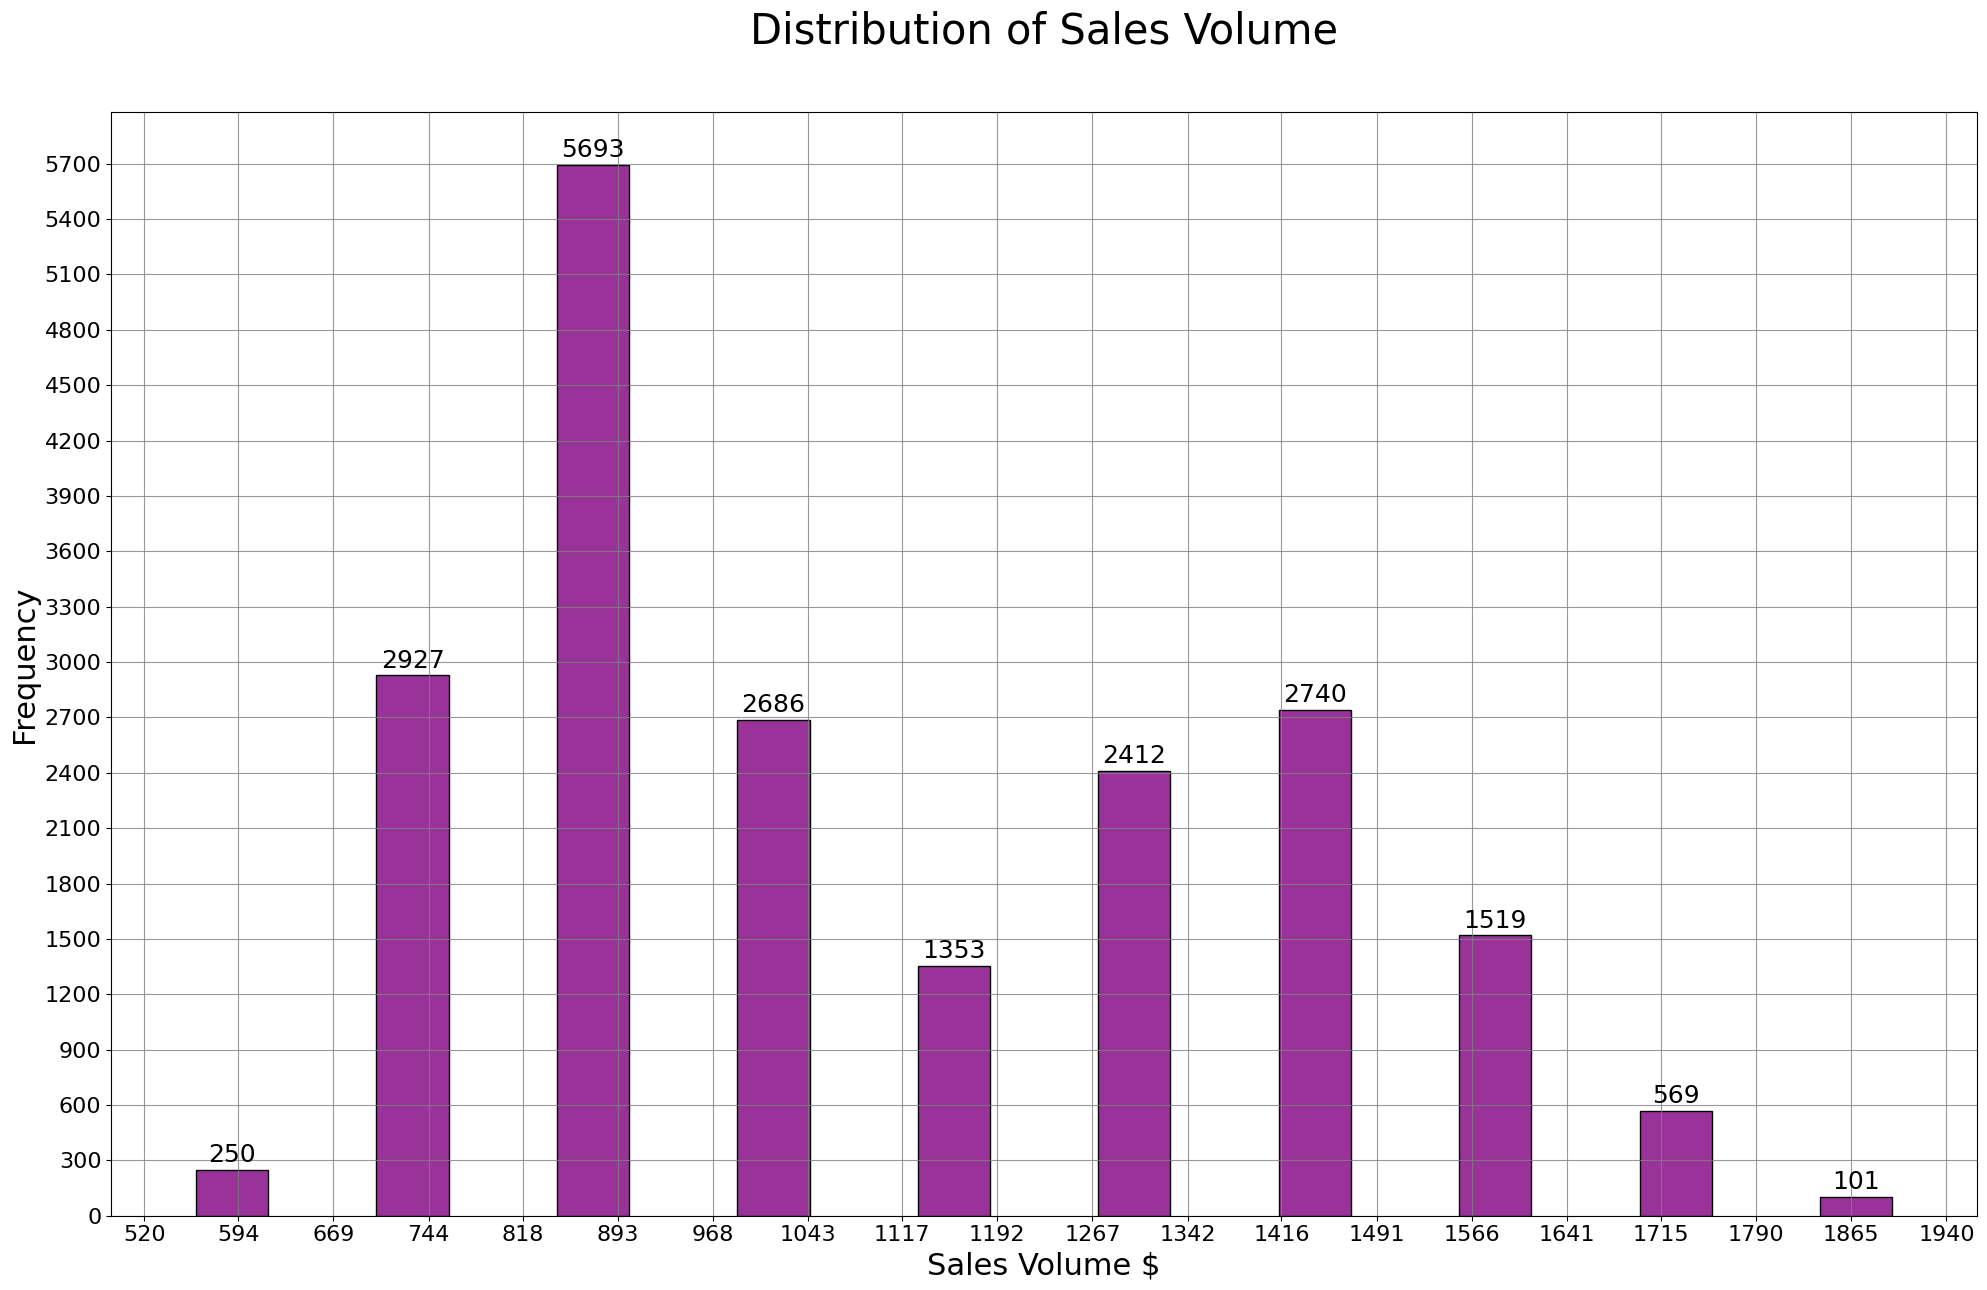

In [35]:
plt.figure(figsize=(20,13), facecolor="white")

ax=sns.histplot(df['Sales Volume'], bins=10, edgecolor='black', alpha=0.8,color='purple',shrink=0.4)

plt.title("Distribution of Sales Volume", fontsize=30, pad=50)
plt.xlabel("Sales Volume $", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.yticks(range(0,6000,300),fontsize=16)
plt.xticks(np.linspace(520, 1940, 20, dtype=int), fontsize=16)

plt.grid(alpha=0.8,color='gray')

plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)
plt.show()

In [36]:
df['Seasonal'].value_counts()

Seasonal
No     10136
Yes    10114
Name: count, dtype: int64

In [37]:
df['Product Category'].value_counts()

Product Category
clothing    20250
Name: count, dtype: int64

In [38]:
df['Promotion'].value_counts()

Promotion
No     11810
Yes     8440
Name: count, dtype: int64

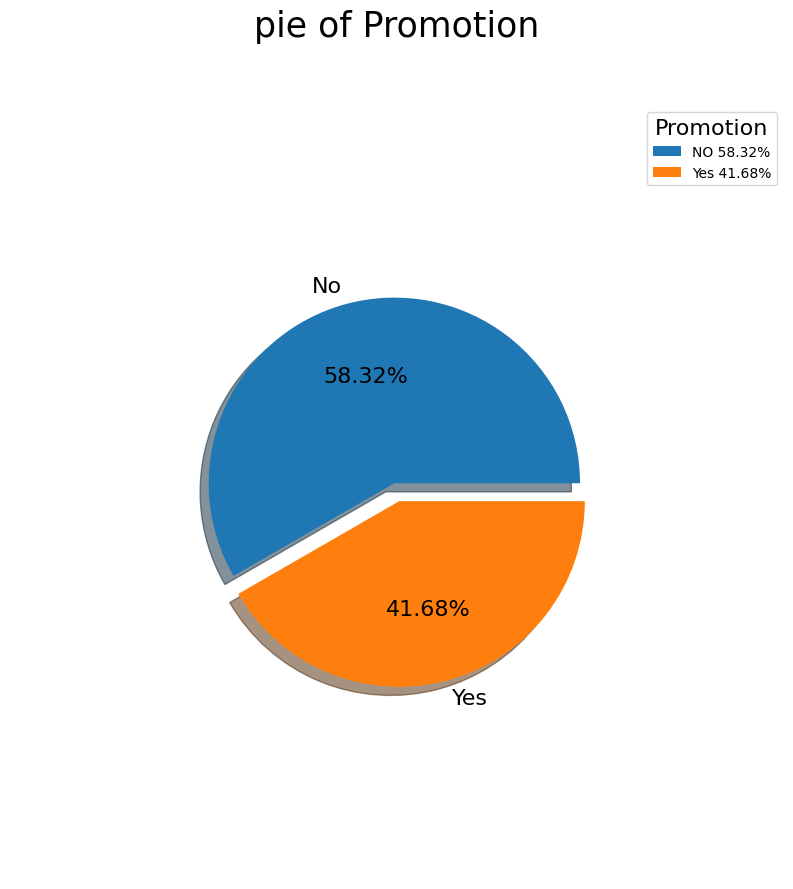

In [39]:
plt.figure(figsize=(18,9), facecolor="white")
Promotion = df['Promotion'].value_counts()
colors = sns.color_palette('tab10', n_colors=len(Promotion))
plt.pie(df['Promotion'].value_counts().values,labels=df['Promotion'].value_counts().index,colors=colors,
                explode=[0.03]*2,autopct='%1.2f%%',shadow=True,radius=0.6,counterclock=True,textprops={'fontsize':16},
        frame=False,rotatelabels=False)
plt.title("pie of Promotion", fontsize=25, pad=50)
plt.tight_layout()
plt.legend(loc='upper right',title='Promotion',title_fontsize=16,labels=['NO 58.32%','Yes 41.68%'])
plt.show()

In [40]:
df['Product Position'].value_counts()

Product Position
Aisle             7810
End-cap           6789
Front of Store    5651
Name: count, dtype: int64

In [41]:
df['Product ID'].describe()

count     20250.000000
mean     208935.993383
std        8949.110701
min      110075.000000
25%      204444.250000
50%      209506.500000
75%      214568.750000
max      219631.000000
Name: Product ID, dtype: float64

In [42]:
df[['Product Position','Promotion','Product Category','Seasonal','brand','url','name','description','currency','terms','section','season','material','origin']].value_counts()

Product Position  Promotion  Product Category  Seasonal  brand  url                                                                       name                                               description                                                                                                                                                                                                 currency  terms     section  season  material     origin    
Front of Store    Yes        clothing          Yes       Zara   https://www.zara.com/us/en/zippered-wool-blend-overshirt-p05854401.html   TEXTURED RIB COLLAR JACKET SAND                    Cropped fit T-shirt with round neck and short sleeves. Contrasting front and back prints. Washed effect.                                                                                                    USD       jackets   MAN      Summer  Linen        Brazil        1
Aisle             No         clothing          No        Zara   https://www.zara.com/us

In [43]:
df[['Product Position','Promotion','Product Category','Seasonal','brand','url','name','description','currency','terms','section','season','material','origin']].describe()

,Product Position,Promotion,Product Category,Seasonal,brand,url,name,description,currency,terms,section,season,material,origin
count,20250,20250,20250,20250,20250,20250,20250,20250,20250,20250,20250,20250,20250,20250
unique,3,2,1,2,1,228,17215,221,1,5,2,4,11,12
top,Aisle,No,clothing,No,Zara,https://www.zara.com/us/en/knit-sweater-with-r...,PLAID OVERSHIRT,Varsity jacket with elastic collar and long sl...,USD,jackets,WOMAN,Autumn,Cotton,China
freq,7810,11810,20250,10136,20250,187,8,333,20250,11230,13253,7664,3850,4026


In [44]:
df[['Product ID','Sales Volume','price']].describe()

,Product ID,Sales Volume,price
count,20250.000000,20250.000000,20250.000000
mean,208935.993383,1097.428148,41.950592
std,8949.110701,298.236187,23.381581
min,110075.000000,518.000000,12.000000
25%,204444.250000,849.000000,23.950000
50%,209506.500000,990.000000,35.950000
75%,214568.750000,1364.750000,53.950000
max,219631.000000,1940.000000,134.990000



#### **biavariate Analysis**

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20250 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20250 non-null  int64  
 1   Product Position  20250 non-null  object 
 2   Promotion         20250 non-null  object 
 3   Product Category  20250 non-null  object 
 4   Seasonal          20250 non-null  object 
 5   Sales Volume      20250 non-null  int64  
 6   brand             20250 non-null  object 
 7   url               20250 non-null  object 
 8   name              20250 non-null  object 
 9   description       20250 non-null  object 
 10  price             20250 non-null  float64
 11  currency          20250 non-null  object 
 12  terms             20250 non-null  object 
 13  section           20250 non-null  object 
 14  season            20250 non-null  object 
 15  material          20250 non-null  object 
 16  origin            20250 non-null  object 
dty

# material × price

In [46]:
df.groupby(['material'])['price'].value_counts()

material    price 
Acrylic     19.99     25
            17.99     23
            21.99     23
            29.99     22
            22.99     21
                      ..
Wool Blend  130.99     1
            132.99     1
            133.95     1
            133.99     1
            134.99     1
Name: count, Length: 2216, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\1389741874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='material', y='price', data=df, palette='Set1')


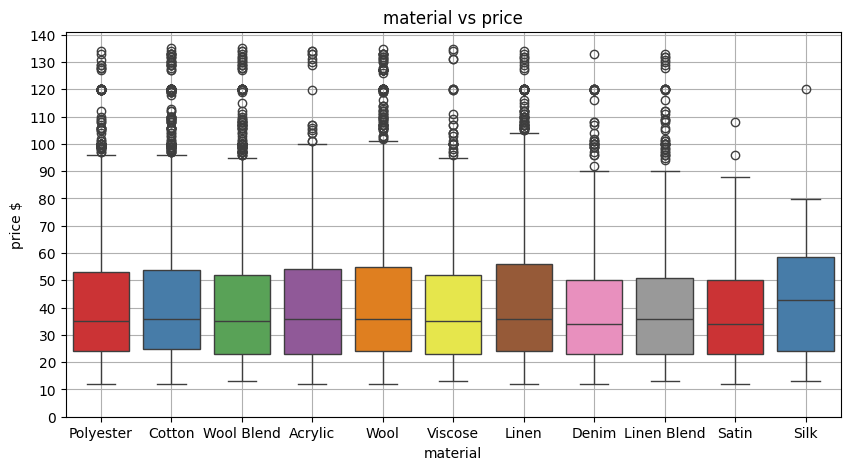

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='material', y='price', data=df, palette='Set1')
plt.title('material vs price')
plt.xlabel('material')
plt.yticks(range(0,150,10))

plt.ylabel('price $')
plt.grid(True)
plt.show()

# Promotion and	Sales Volume	

In [48]:
df.groupby(['Promotion'])['Sales Volume'].value_counts()

Promotion  Sales Volume
No         848             60
           829             59
           838             54
           864             54
           867             54
                           ..
Yes        1906             1
           1912             1
           1917             1
           1926             1
           1929             1
Name: count, Length: 1463, dtype: int64

In [49]:
df.groupby(['Promotion'])['Sales Volume'].mean()

Promotion
No      872.386452
Yes    1412.326540
Name: Sales Volume, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\2088391160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Promotion', y='Sales Volume', data=df, estimator='mean', palette='Set1',width=0.1)


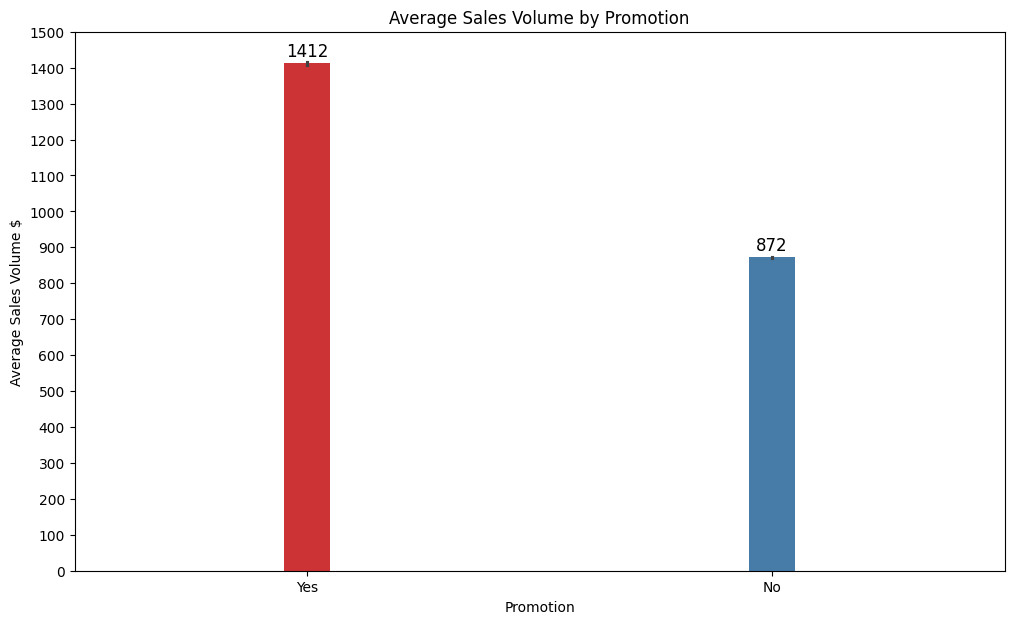

In [50]:
plt.figure(figsize=(12, 7))
ax=sns.barplot(x='Promotion', y='Sales Volume', data=df, estimator='mean', palette='Set1',width=0.1)
plt.title('Average Sales Volume by Promotion')
plt.xlabel('Promotion')
plt.yticks(range(0,1550,100))
plt.ylabel('Average Sales Volume $')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)
plt.show()


# Product Position and price

In [51]:
df.groupby(['Product Position'])['price'].value_counts()

Product Position  price 
Aisle             19.99     269
                  29.99     251
                  25.99     231
                  39.99     197
                  22.99     191
                           ... 
Front of Store    128.00      1
                  128.95      1
                  128.99      1
                  131.95      1
                  134.95      1
Name: count, Length: 891, dtype: int64

In [52]:
df.groupby(['Product Position'])['price'].mean()


Product Position
Aisle             42.120601
End-cap           41.718583
Front of Store    41.994360
Name: price, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\4140825053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Position', y='price', data=df, palette='Set1')


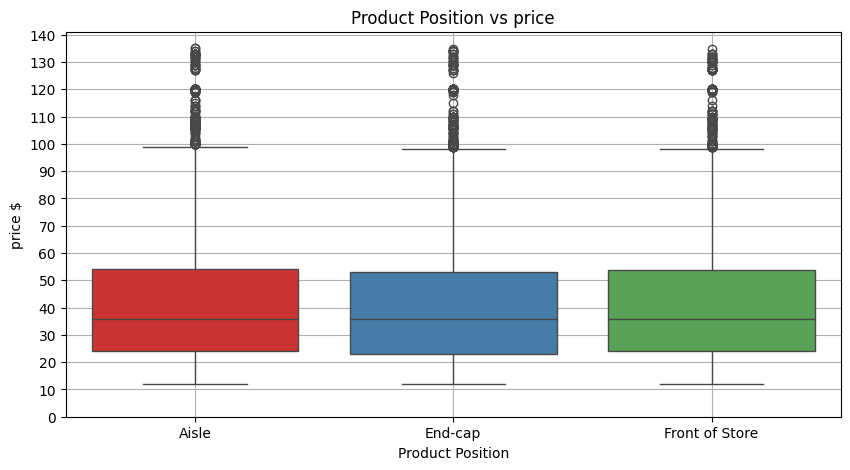

In [53]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Product Position', y='price', data=df, palette='Set1')
plt.title('Product Position vs price')
plt.xlabel('Product Position')
plt.yticks(range(0,150,10))

plt.ylabel('price $')
plt.grid(True)
plt.show()

# origin and price	

In [54]:
df.groupby(['origin'])['price'].value_counts()

origin     price 
Argentina  25.99     8
           22.99     7
           29.99     7
           21.99     5
           25.95     5
                    ..
Vietnam    111.99    1
           114.99    1
           130.99    1
           132.95    1
           132.99    1
Name: count, Length: 2597, dtype: int64

In [55]:
df.groupby(['origin'])['price'].mean()

origin
Argentina     39.314860
Bangladesh    42.026364
Brazil        39.841447
Cambodia      42.048612
China         41.522273
India         42.553340
Morocco       42.744743
Pakistan      41.404893
Portugal      42.246871
Spain         41.828630
Turkey        42.501564
Vietnam       41.674369
Name: price, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\1687990833.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='origin', y='price', data=df, palette='Set2')


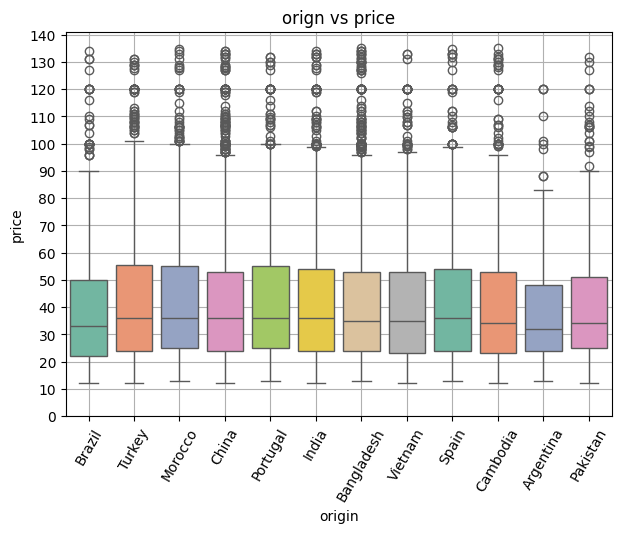

In [56]:

sns.boxplot(x='origin', y='price', data=df, palette='Set2')
plt.title('orign vs price')
plt.tight_layout()
plt.yticks(range(0,150,10))

plt.grid(True)
plt.xticks(rotation=60)
plt.show()

#  season and	price	

In [57]:
df.groupby(['season'])['price'].value_counts()

season  price 
Autumn  19.99     390
        29.99     364
        25.99     273
        39.99     266
        35.99     250
                 ... 
Winter  128.00      1
        129.00      1
        131.95      1
        133.00      1
        134.99      1
Name: count, Length: 1072, dtype: int64

In [58]:
df.groupby(['season'])['price'].mean()

season
Autumn    40.528180
Spring    40.739026
Summer    44.081700
Winter    43.934267
Name: price, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\3797999411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='season',y='price',data=df,palette='hls',width=0.4)


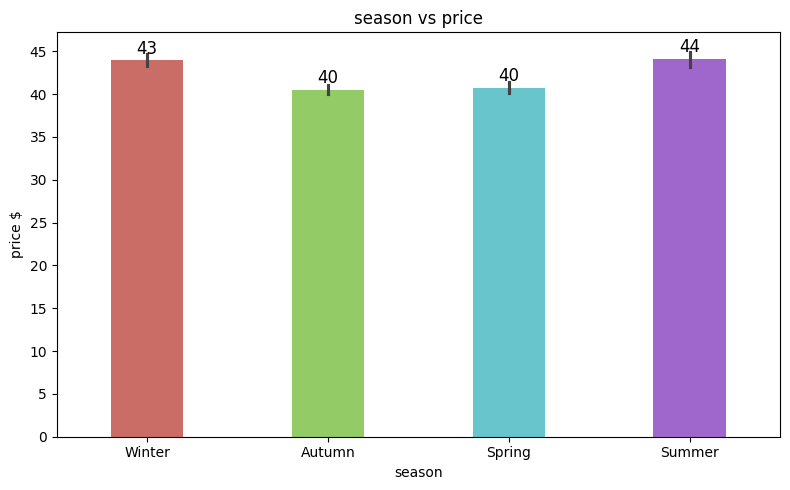

In [59]:
plt.figure(figsize=(8, 5))
ax=sns.barplot(x='season',y='price',data=df,palette='hls',width=0.4)
plt.title('season vs price')
plt.xlabel('season')
plt.yticks(range(0,50,5))

plt.ylabel('price $')
plt.grid(False)
plt.xticks()
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)
plt.show()

# multivariate analysis

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20250 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20250 non-null  int64  
 1   Product Position  20250 non-null  object 
 2   Promotion         20250 non-null  object 
 3   Product Category  20250 non-null  object 
 4   Seasonal          20250 non-null  object 
 5   Sales Volume      20250 non-null  int64  
 6   brand             20250 non-null  object 
 7   url               20250 non-null  object 
 8   name              20250 non-null  object 
 9   description       20250 non-null  object 
 10  price             20250 non-null  float64
 11  currency          20250 non-null  object 
 12  terms             20250 non-null  object 
 13  section           20250 non-null  object 
 14  season            20250 non-null  object 
 15  material          20250 non-null  object 
 16  origin            20250 non-null  object 
dty

# season,Sales Volume,price

In [61]:
df.groupby(['season','price'])['Sales Volume'].value_counts()

season  price   Sales Volume
Autumn  12.00   1343            1
                1393            1
                1413            1
                1441            1
                1638            1
                               ..
Winter  133.99  741             1
                746             1
        134.95  631             1
                751             1
        134.99  671             1
Name: count, Length: 18222, dtype: int64

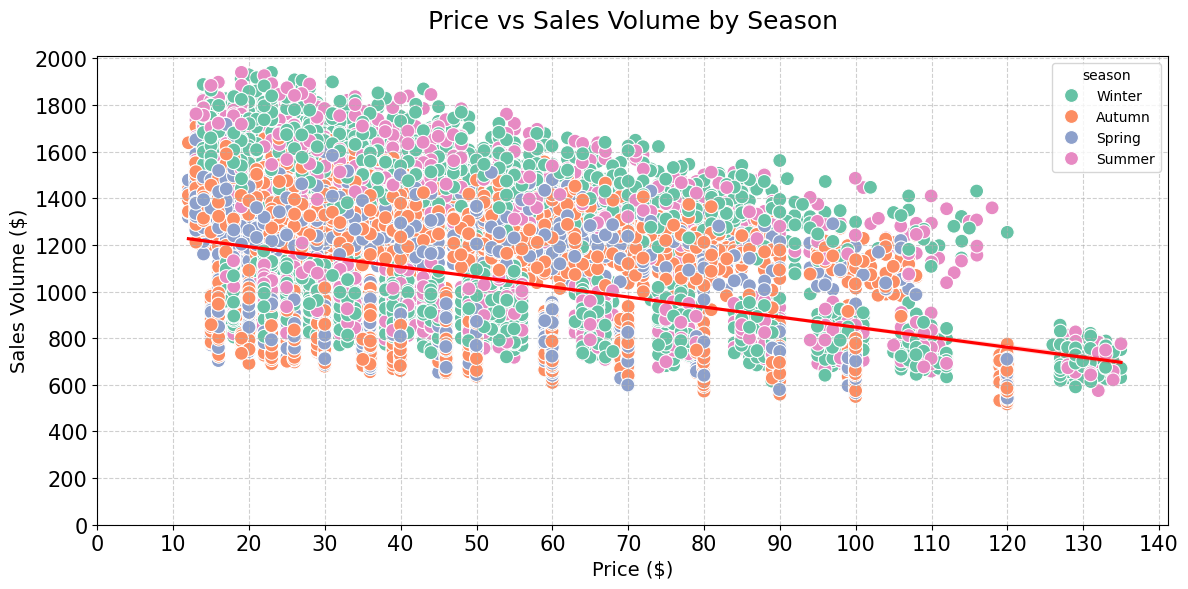

In [62]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='price', y='Sales Volume', hue='season', data=df, palette='Set2',s=100)
sns.regplot(x='price', y='Sales Volume', data=df, scatter=False, color='red')
plt.title('Price vs Sales Volume by Season', fontsize=18, pad=20)
plt.xlabel('Price ($)', fontsize=14)
plt.ylabel('Sales Volume ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0,150,10), fontsize=15)
plt.yticks(range(0,2100,200), fontsize=15)

plt.tight_layout()
plt.show()


# Promotion + season + Sales Volume

In [63]:
df.groupby(['Promotion','season'])['Sales Volume'].value_counts()

Promotion  season  Sales Volume
No         Autumn  848             30
                   798             29
                   846             28
                   854             28
                   867             28
                                   ..
Yes        Winter  1908             1
                   1912             1
                   1917             1
                   1929             1
                   1940             1
Name: count, Length: 4105, dtype: int64

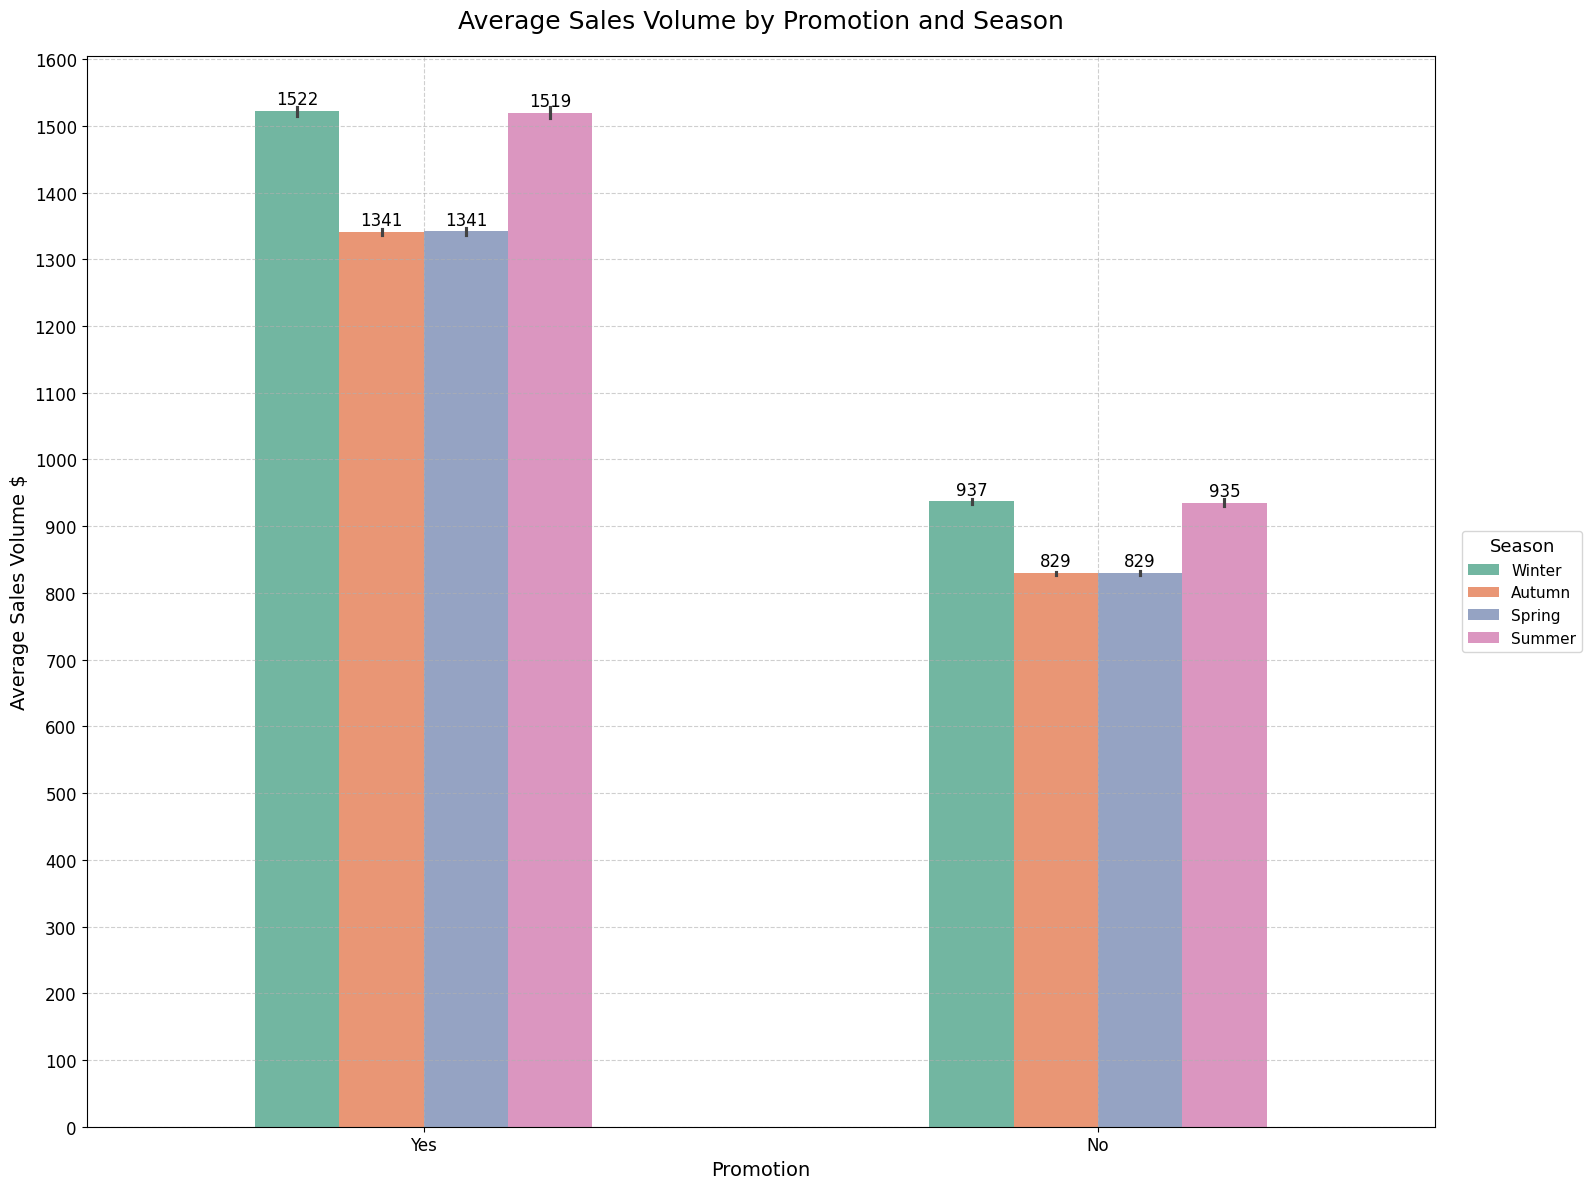

In [64]:
plt.figure(figsize=(16, 12))

ax=sns.barplot(x='Promotion', y='Sales Volume', hue='season', data=df, estimator='mean', palette='Set2',width=0.5)

plt.title('Average Sales Volume by Promotion and Season', fontsize=18, pad=20)
plt.xlabel('Promotion', fontsize=14)
plt.ylabel('Average Sales Volume $', fontsize=14)

plt.yticks(range(0, 1650, 100), fontsize=12)
plt.xticks(fontsize=12)

plt.legend(title='Season', title_fontsize=13, fontsize=11, 
           loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)
plt.show()


# Product Position + season + price

In [65]:
pd.pivot_table(df, index='Product Position', columns='season', values='price', aggfunc='mean')


season,Autumn,Spring,Summer,Winter
Product Position,,,,
Aisle,40.643889,40.664539,44.696020,44.118194
End-cap,40.563238,40.816680,43.490031,43.295411
Front of Store,40.327571,40.756277,43.942965,44.422837


In [66]:
df.groupby(['Product Position','season'])['price'].value_counts()

Product Position  season  price 
Aisle             Autumn  19.99     151
                          29.99     151
                          25.99     110
                          35.99      98
                          39.99      93
                                   ... 
Front of Store    Winter  127.95      1
                          128.00      1
                          130.95      1
                          131.99      1
                          134.95      1
Name: count, Length: 2573, dtype: int64

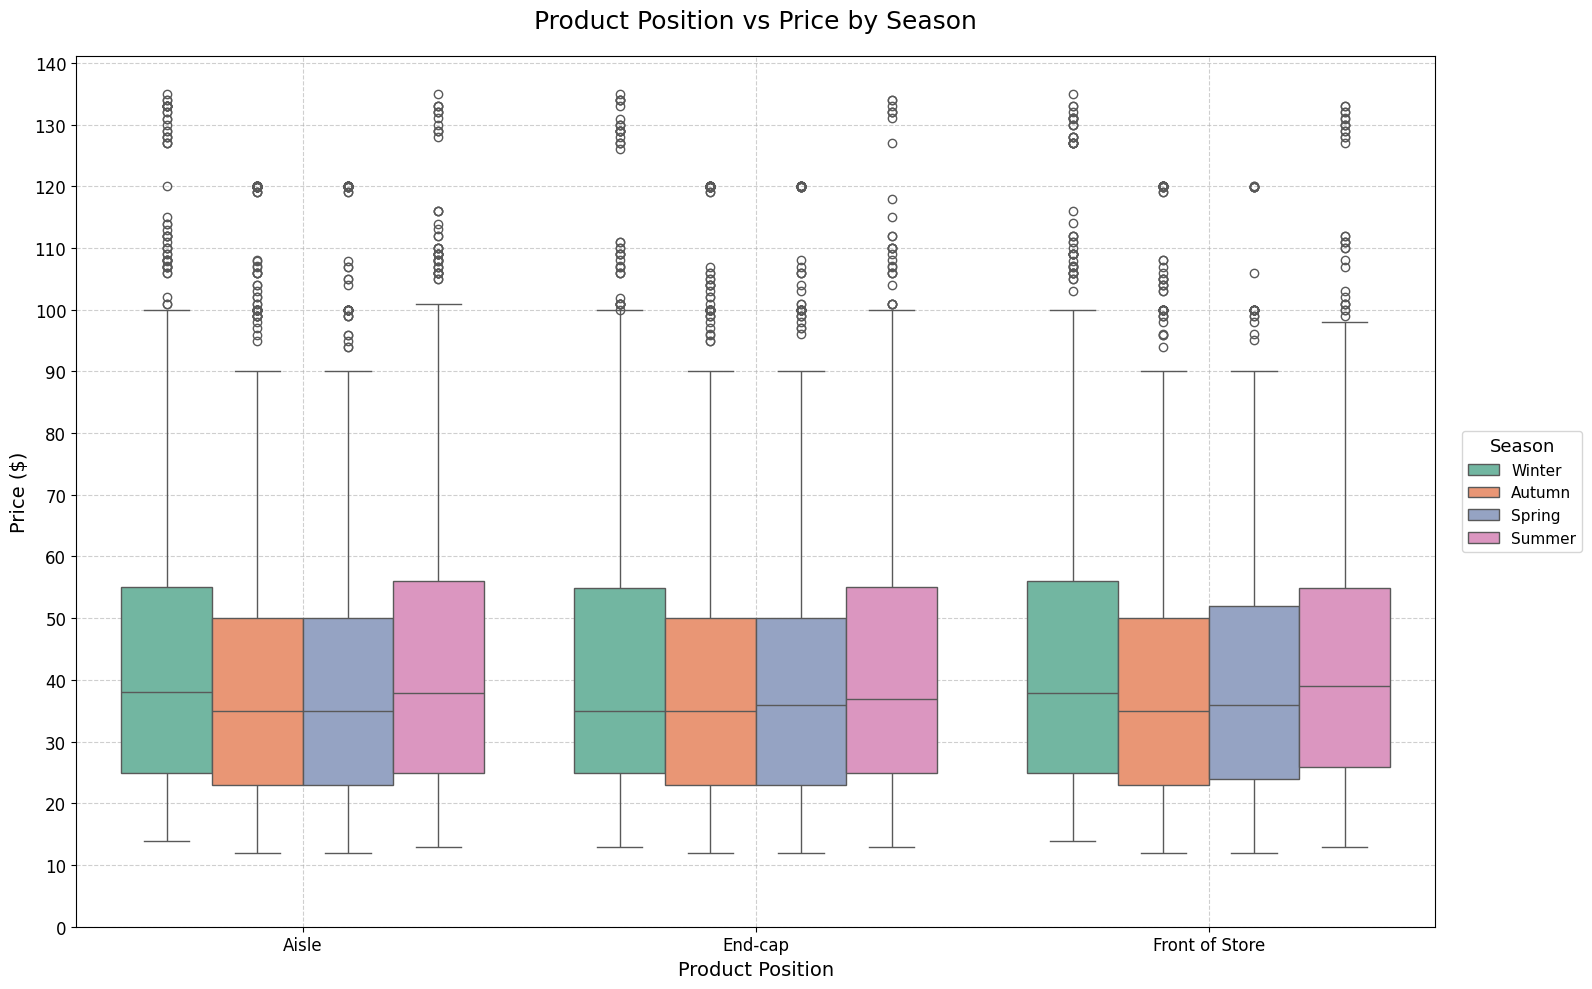

In [67]:
plt.figure(figsize=(16, 10))
sns.boxplot(x='Product Position', y='price', hue='season', data=df, palette='Set2')

plt.title('Product Position vs Price by Season', fontsize=18, pad=20)
plt.xlabel('Product Position', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)

plt.yticks(range(0, 150, 10), fontsize=12)
plt.xticks(fontsize=12)

plt.legend(title='Season', title_fontsize=13, fontsize=11, 
           loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\796177841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='material', y='price', data=df, palette='Set1')
C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\796177841.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Promotion', y='Sales Volume', data=df, estimator='mean', palette='Set1',width=0.1)
C:\Users\Mega\AppData\Local\Temp\ipykernel_20892\796177841.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Position', y='price', data=df, palette='Set1')
C:\Users\Mega\A

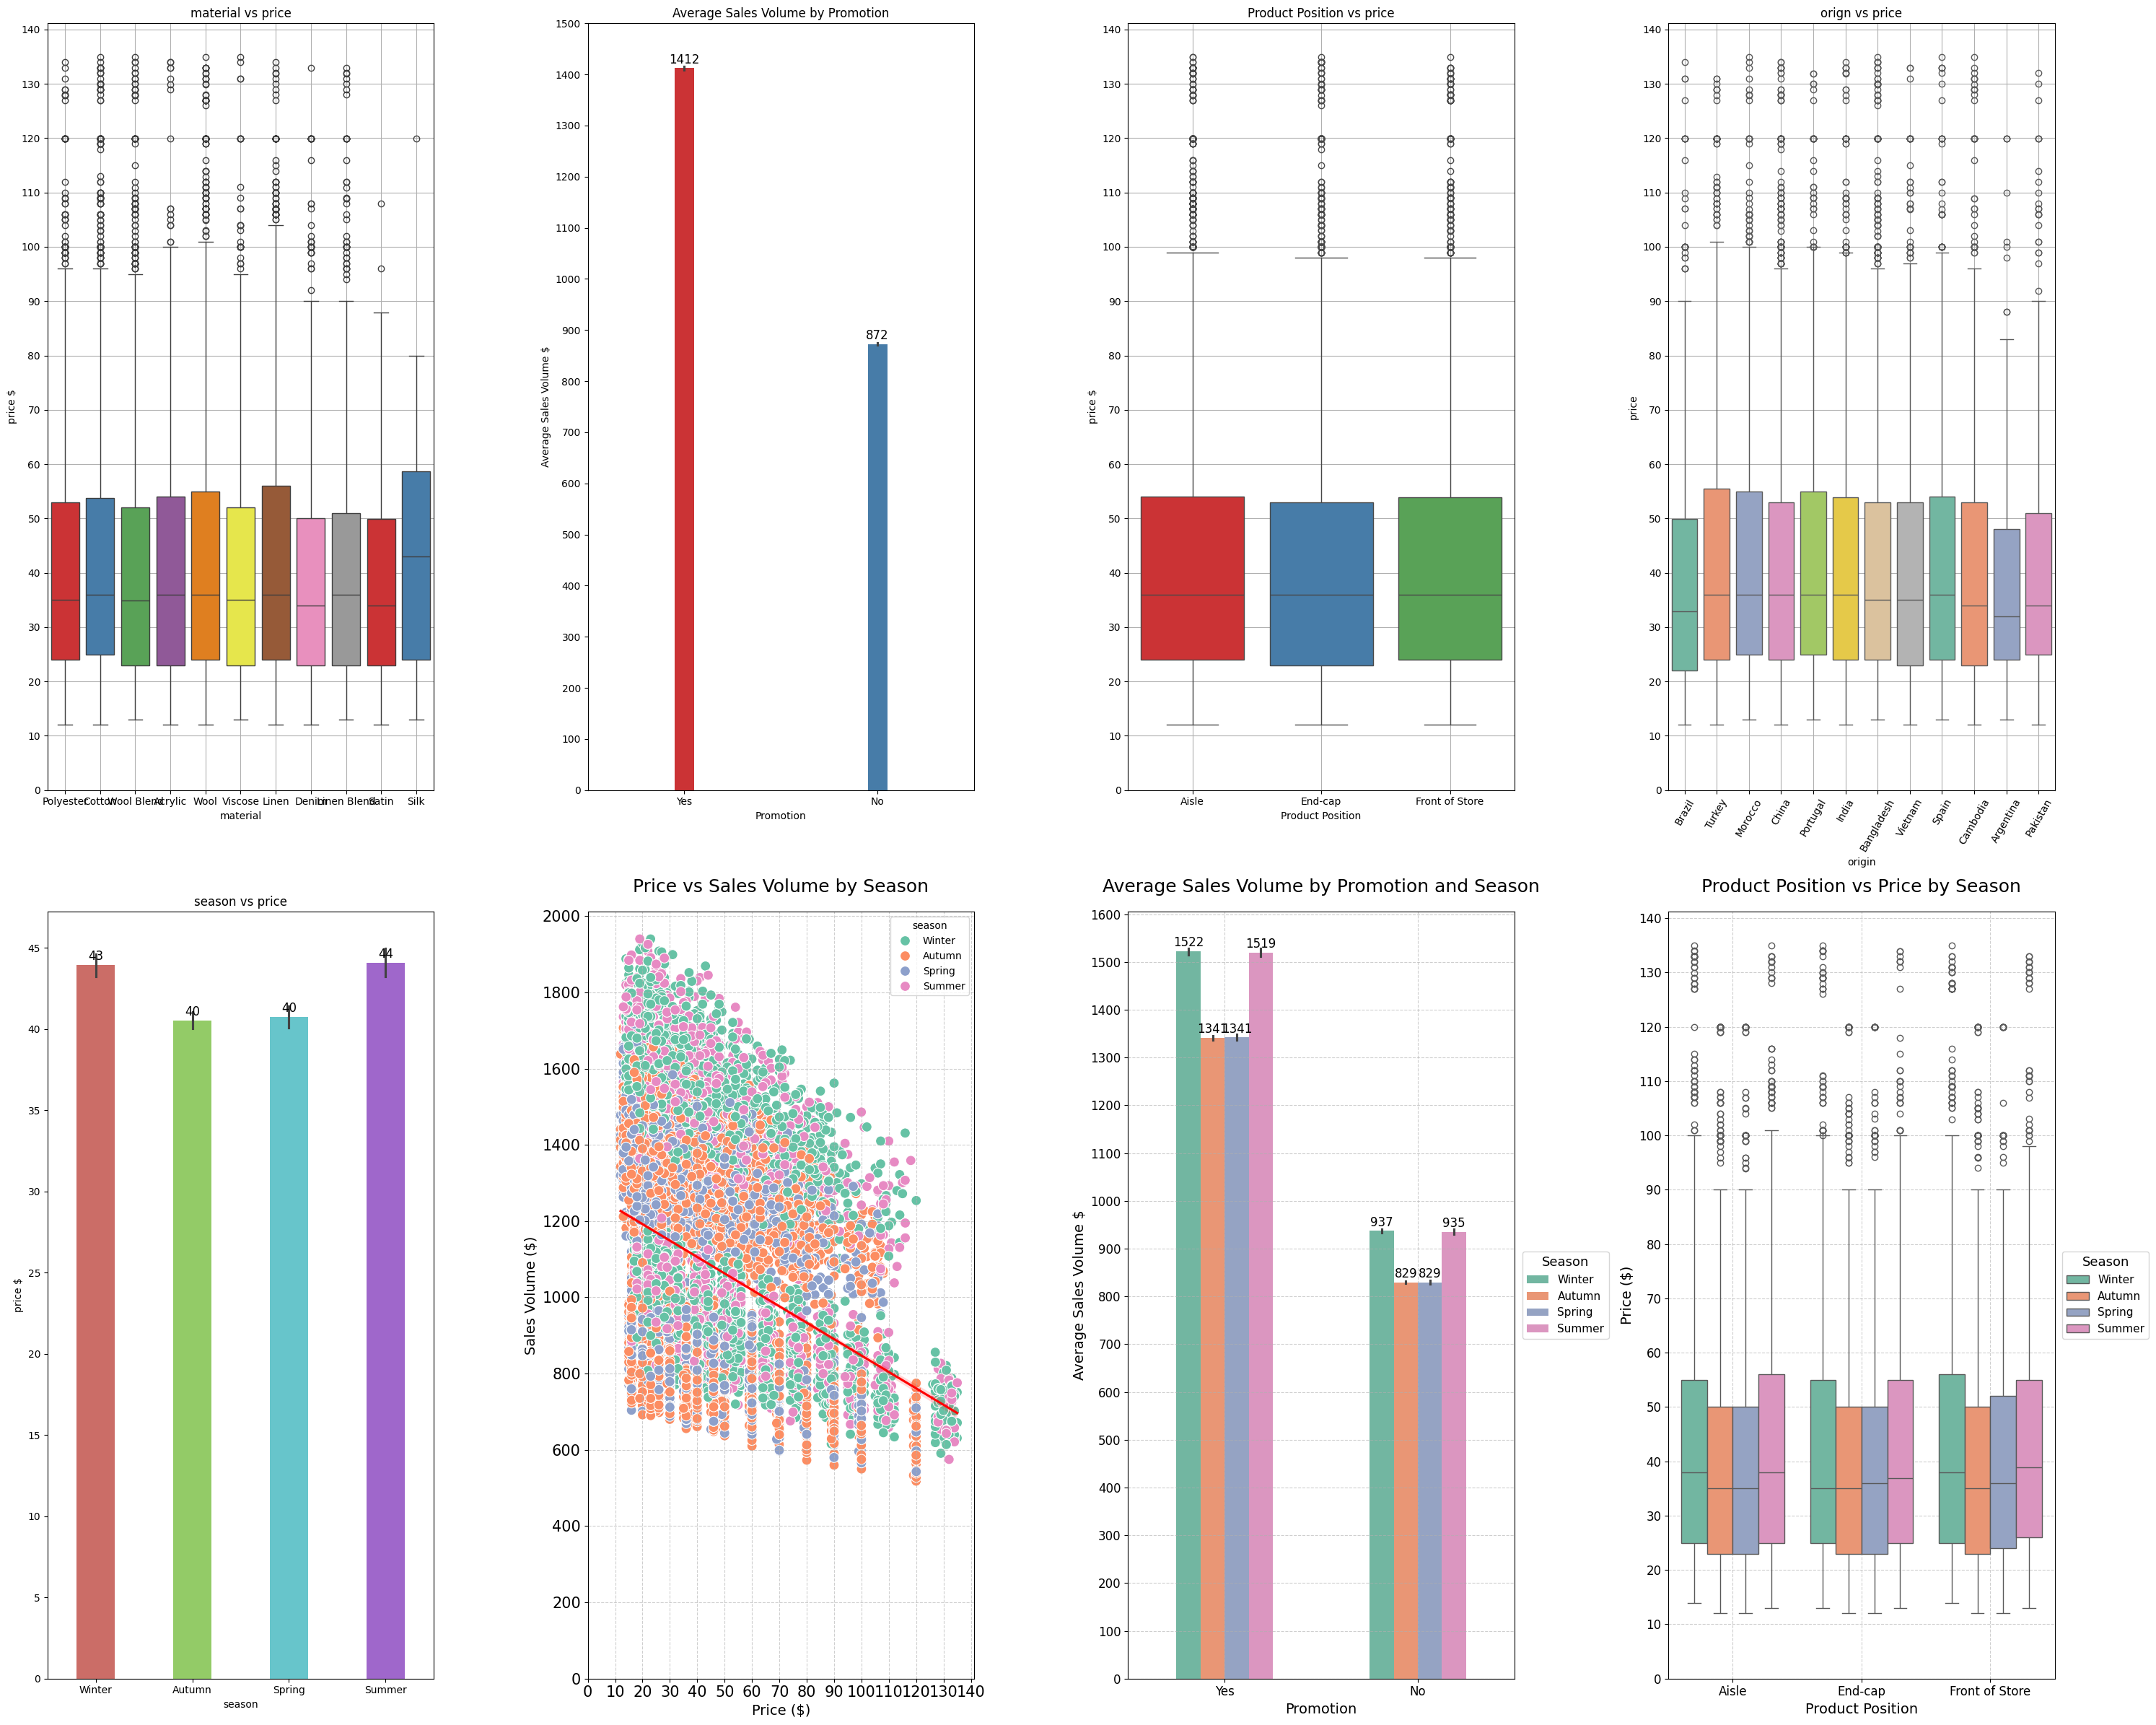

In [68]:
plt.figure(figsize=(30,24))
# subplot 1: material vs price
plt.subplot(2,4,1)

sns.boxplot(x='material', y='price', data=df, palette='Set1')
plt.title('material vs price')
plt.xlabel('material')
plt.yticks(range(0,150,10))

plt.ylabel('price $')
plt.grid(True)




# subplot 2: Average Sales Volume by Promotion
plt.subplot(2,4,2)


ax=sns.barplot(x='Promotion', y='Sales Volume', data=df, estimator='mean', palette='Set1',width=0.1)
plt.title('Average Sales Volume by Promotion')
plt.xlabel('Promotion')
plt.yticks(range(0,1550,100))
plt.ylabel('Average Sales Volume $')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)


# subplot 3: Product Position vs price
plt.subplot(2,4,3)


sns.boxplot(x='Product Position', y='price', data=df, palette='Set1')
plt.title('Product Position vs price')
plt.xlabel('Product Position')
plt.yticks(range(0,150,10))

plt.ylabel('price $')
plt.grid(True)

# subplot 4: orign vs price
plt.subplot(2,4,4)


sns.boxplot(x='origin', y='price', data=df, palette='Set2')
plt.title('orign vs price')
plt.tight_layout()
plt.yticks(range(0,150,10))

plt.grid(True)
plt.xticks(rotation=60)

# subplot 5: season vs price
plt.subplot(2,4,5)


ax=sns.barplot(x='season',y='price',data=df,palette='hls',width=0.4)
plt.title('season vs price')
plt.xlabel('season')
plt.yticks(range(0,50,5))

plt.ylabel('price $')
plt.grid(False)
plt.xticks()
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)

# subplot 6: Price vs Sales Volume by Season
plt.subplot(2,4,6)


sns.scatterplot(x='price', y='Sales Volume', hue='season', data=df, palette='Set2',s=100)
sns.regplot(x='price', y='Sales Volume', data=df, scatter=False, color='red')
plt.title('Price vs Sales Volume by Season', fontsize=18, pad=20)
plt.xlabel('Price ($)', fontsize=14)
plt.ylabel('Sales Volume ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0,150,10), fontsize=15)
plt.yticks(range(0,2100,200), fontsize=15)

plt.tight_layout()

# subplot 7: Average Sales Volume by Promotion and Season
plt.subplot(2,4,7)



ax=sns.barplot(x='Promotion', y='Sales Volume', hue='season', data=df, estimator='mean', palette='Set2',width=0.5)

plt.title('Average Sales Volume by Promotion and Season', fontsize=18, pad=20)
plt.xlabel('Promotion', fontsize=14)
plt.ylabel('Average Sales Volume $', fontsize=14)

plt.yticks(range(0, 1650, 100), fontsize=12)
plt.xticks(fontsize=12)

plt.legend(title='Season', title_fontsize=13, fontsize=11, 
           loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)

# subplot 8: Product Position vs Price by Season
plt.subplot(2,4,8)


sns.boxplot(x='Product Position', y='price', hue='season', data=df, palette='Set2')

plt.title('Product Position vs Price by Season', fontsize=18, pad=20)
plt.xlabel('Product Position', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)

plt.yticks(range(0, 150, 10), fontsize=12)
plt.xticks(fontsize=12)

plt.legend(title='Season', title_fontsize=13, fontsize=11, 
           loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()



## **Preprocessing**

# drop unneeded columns

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20250 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20250 non-null  int64  
 1   Product Position  20250 non-null  object 
 2   Promotion         20250 non-null  object 
 3   Product Category  20250 non-null  object 
 4   Seasonal          20250 non-null  object 
 5   Sales Volume      20250 non-null  int64  
 6   brand             20250 non-null  object 
 7   url               20250 non-null  object 
 8   name              20250 non-null  object 
 9   description       20250 non-null  object 
 10  price             20250 non-null  float64
 11  currency          20250 non-null  object 
 12  terms             20250 non-null  object 
 13  section           20250 non-null  object 
 14  season            20250 non-null  object 
 15  material          20250 non-null  object 
 16  origin            20250 non-null  object 
dty

In [70]:
df.drop(columns=['Product ID','url','name','description'],inplace=True)

# x and y

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20250 entries, 0 to 20251
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Position  20250 non-null  object 
 1   Promotion         20250 non-null  object 
 2   Product Category  20250 non-null  object 
 3   Seasonal          20250 non-null  object 
 4   Sales Volume      20250 non-null  int64  
 5   brand             20250 non-null  object 
 6   price             20250 non-null  float64
 7   currency          20250 non-null  object 
 8   terms             20250 non-null  object 
 9   section           20250 non-null  object 
 10  season            20250 non-null  object 
 11  material          20250 non-null  object 
 12  origin            20250 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 2.2+ MB


In [72]:
x=df.drop('Sales Volume',axis=1)
y=df['Sales Volume']

In [73]:
x

,Product Position,Promotion,Product Category,Seasonal,brand,price,currency,terms,section,season,material,origin
0,Aisle,Yes,clothing,Yes,Zara,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,Aisle,Yes,clothing,No,Zara,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,End-cap,Yes,clothing,Yes,Zara,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,Aisle,Yes,clothing,No,Zara,30.99,USD,jackets,MAN,Spring,Polyester,China
4,End-cap,Yes,clothing,Yes,Zara,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China
...,...,...,...,...,...,...,...,...,...,...,...,...
20247,Front of Store,Yes,clothing,No,Zara,31.95,USD,jeans,WOMAN,Summer,Linen Blend,India
20248,Aisle,No,clothing,No,Zara,49.99,USD,jackets,WOMAN,Spring,Linen,China
20249,Aisle,Yes,clothing,No,Zara,20.99,USD,shoes,WOMAN,Spring,Polyester,China
20250,Aisle,No,clothing,No,Zara,64.95,USD,jackets,WOMAN,Winter,Polyester,Spain


In [74]:
y

0        1243
1        1429
2        1168
3        1348
4        1602
         ... 
20247    1754
20248     872
20249    1360
20250     892
20251     859
Name: Sales Volume, Length: 20250, dtype: int64

# label encoder

In [75]:
encoder=LabelEncoder()
x['Product Position']=encoder.fit_transform(x['Product Position'])
x['Promotion']=encoder.fit_transform(x['Promotion'])
x['Product Category']=encoder.fit_transform(x['Product Category'])
x['Seasonal']=encoder.fit_transform(x['Seasonal'])
x['brand']=encoder.fit_transform(x['brand'])
x['currency']=encoder.fit_transform(x['currency'])
x['terms']=encoder.fit_transform(x['terms'])
x['section']=encoder.fit_transform(x['section'])
x['season']=encoder.fit_transform(x['season'])
x['material']=encoder.fit_transform(x['material'])
x['origin']=encoder.fit_transform(x['origin'])



In [76]:
x

,Product Position,Promotion,Product Category,Seasonal,brand,price,currency,terms,section,season,material,origin
0,0,1,0,1,0,78.99,0,0,0,3,5,2
1,0,1,0,0,0,14.99,0,0,0,0,1,10
2,1,1,0,1,0,71.95,0,0,1,0,5,6
3,0,1,0,0,0,30.99,0,0,0,1,5,4
4,1,1,0,1,0,22.99,0,0,1,3,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...
20247,2,1,0,0,0,31.95,0,1,1,2,4,5
20248,0,0,0,0,0,49.99,0,0,1,1,3,4
20249,0,1,0,0,0,20.99,0,2,1,1,5,4
20250,0,0,0,0,0,64.95,0,0,1,3,5,9


In [77]:
y

0        1243
1        1429
2        1168
3        1348
4        1602
         ... 
20247    1754
20248     872
20249    1360
20250     892
20251     859
Name: Sales Volume, Length: 20250, dtype: int64

# scaling

In [78]:
scaler=MinMaxScaler()
x=scaler.fit_transform(x)

In [79]:
y=scaler.fit_transform(y.values.reshape(-1,1))

In [80]:
x

array([[0.        , 1.        , 0.        , ..., 1.        , 0.5       ,
        0.18181818],
       [0.        , 1.        , 0.        , ..., 0.        , 0.1       ,
        0.90909091],
       [0.5       , 1.        , 0.        , ..., 0.        , 0.5       ,
        0.54545455],
       ...,
       [0.        , 1.        , 0.        , ..., 0.33333333, 0.5       ,
        0.36363636],
       [0.        , 0.        , 0.        , ..., 1.        , 0.5       ,
        0.81818182],
       [0.        , 0.        , 0.        , ..., 0.66666667, 0.3       ,
        0.90909091]], shape=(20250, 12))

In [81]:
y

array([[0.50984529],
       [0.64064698],
       [0.45710267],
       ...,
       [0.59212377],
       [0.26300985],
       [0.23980309]], shape=(20250, 1))

#  data split

In [82]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

# LinearRegression,Lasso,Ridge,SGDRegressor

In [83]:
lr=LinearRegression(tol=0.0,n_jobs=2)
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,0.0
,n_jobs,2
,positive,False


In [84]:
lr.score(x_train,y_train)

0.9212971634690656

In [85]:
lr.score(x_test,y_test)

0.9200728969798826

In [86]:
y_pred=lr.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.04663013785143047


In [87]:
y_pred=lr.predict(x_test)

print(mean_absolute_error(y_pred,y_test))

0.04556661792432611


In [88]:
lasso=Lasso(alpha=0.0,max_iter=1200)
lasso.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.838e+01, tolerance: 7.213e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in 

,alpha,0.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1200
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [89]:
lasso.score(x_train,y_train)

0.9212971634690656

In [90]:
lasso.score(x_test,y_test)

0.9200728969798831

In [91]:
y_pred=lasso.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0466301378514303


In [92]:
y_pred=lasso.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.045566617924325724


In [93]:
ridge=Ridge(alpha=0.0,tol=0)
ridge.fit(x_train,y_train)

,alpha,0.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0
,solver,'auto'
,positive,False
,random_state,None


In [94]:
ridge.score(x_train,y_train)

0.9212841194676034

In [95]:
ridge.score(x_test,y_test)

0.9200190053976119

In [96]:
y_pred=ridge.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.04662789730247825


In [97]:
y_pred=ridge.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04556977465560486


In [98]:
sgd=SGDRegressor(loss='squared_error',alpha=0)
sgd.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [99]:
sgd.score(x_train,y_train)

0.9209073778931381

In [100]:
sgd.score(x_test,y_test)

0.9193431949807602

In [101]:
y_pred=sgd.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.04660114393516545


In [102]:
y_pred=sgd.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04569816230254618


# DecisionTreeRegressor

In [103]:
tree=DecisionTreeRegressor(criterion='absolute_error',max_depth=100)
tree.fit(x_train,y_train)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [104]:
tree.score(x_train,y_train)

0.998922616106291

In [105]:
tree.score(x_test,y_test)

0.8625881980674112

In [106]:
y_pred=tree.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.001089579969092393


In [107]:
y_pred=tree.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.05911765727283776


# KNeighborsRegressor

In [108]:
neighbour=KNeighborsRegressor(n_neighbors=1)
neighbour.fit(x_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [109]:
neighbour.score(x_train,y_train)

0.9978520375290785

In [110]:
neighbour.score(x_test,y_test)

0.8535026618359305

In [111]:
y_pred=neighbour.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0011037314858224376


In [112]:
y_pred=neighbour.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.061012137313121835


# SVR

In [113]:
svm=SVR(kernel='rbf',gamma='scale',C=10,epsilon=0.1,tol=0.0001)
svm.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.0001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [114]:
svm.score(x_train,y_train)

0.9358033652886283

In [115]:
svm.score(x_test,y_test)

0.9286068715979761

In [116]:
y_pred=svm.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.04306744404122625


In [117]:
y_pred=svm.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04316383589296319


 RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,AdaBoostRegressor,VotingRegressor

In [118]:
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [119]:
rf.score(x_train,y_train)

0.9894227970206874

In [120]:
rf.score(x_test,y_test)

0.9254335876944163

In [121]:
y_pred=rf.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.016804182869801912


In [122]:
y_pred=rf.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04358550833422219


In [123]:
extra=ExtraTreesRegressor()
extra.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [124]:
extra.score(x_train,y_train)

0.998927634278755

In [125]:
extra.score(x_test,y_test)

0.9168306200831865

In [126]:
y_pred=extra.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0010949338148905313


In [127]:
y_pred=extra.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04587840258605221


In [128]:
bag=BaggingRegressor()
bag.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_bagging.py:583: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [129]:
bag.score(x_train,y_train)

0.9859231848103318

In [130]:
bag.score(x_test,y_test)

0.9188678249099351

In [131]:
y_pred=bag.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.018285480907648432


In [132]:
y_pred=bag.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04571305201457568


In [133]:
ada=AdaBoostRegressor()
ada.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,None


In [134]:
ada.score(x_train,y_train)

0.9224551791995653

In [135]:
ada.score(x_test,y_test)

0.9199736115834896

In [136]:
y_pred=ada.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.046762621338955694


In [137]:
y_pred=ada.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04631516562606015


In [138]:
vot=VotingRegressor(estimators=[('t1',LinearRegression()),
                                ('t2',SVR()),
                                ('t3',KNeighborsRegressor()),
                                ('t4',DecisionTreeRegressor()),
                                ('t5',RandomForestRegressor()),
                                ('t6',ExtraTreesRegressor())])
vot.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimators,"[('t1', ...), ('t2', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,kernel,'rbf'
,degree,3


In [139]:
vot.score(x_train,y_train)

0.9808680421025034

In [140]:
vot.score(x_test,y_test)

0.9288205159929751

In [141]:
y_pred=vot.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.023033296441902724


In [142]:
y_pred=vot.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.042771452833096406


# XGBOOST

In [143]:
xgb=XGBRegressor()
xgb.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [144]:
xgb.score(x_train,y_train)

0.9580641116557587

In [145]:
xgb.score(x_test,y_test)

0.9295069913530865

In [146]:
y_pred=xgb.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.03393340026902918


In [147]:
y_pred=xgb.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.04258616807524807


# LIGHTGBM

In [148]:
light=LGBMRegressor()
light.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 276
[LightGBM] [Info] Number of data points in the train set: 16200, number of used features: 9
[LightGBM] [Info] Start training from score 0.409230


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [149]:
light.score(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.9446093591787869

In [150]:
light.score(x_test,y_test)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.9346641712808039

In [151]:
y_pred=light.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.03925345961737346


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [152]:
y_pred=light.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.041142596755324556


# catboost

In [153]:
cat=CatBoostRegressor()
cat.fit(x_train,y_train)

Learning rate set to 0.063574
0:	learn: 0.1987315	total: 140ms	remaining: 2m 20s
1:	learn: 0.1872139	total: 146ms	remaining: 1m 12s
2:	learn: 0.1765885	total: 150ms	remaining: 50s
3:	learn: 0.1667455	total: 156ms	remaining: 38.8s
4:	learn: 0.1575067	total: 161ms	remaining: 32.1s
5:	learn: 0.1490002	total: 168ms	remaining: 27.8s
6:	learn: 0.1409177	total: 172ms	remaining: 24.5s
7:	learn: 0.1336593	total: 176ms	remaining: 21.9s
8:	learn: 0.1266576	total: 182ms	remaining: 20s
9:	learn: 0.1201965	total: 187ms	remaining: 18.5s
10:	learn: 0.1143046	total: 191ms	remaining: 17.2s
11:	learn: 0.1088827	total: 195ms	remaining: 16.1s
12:	learn: 0.1037194	total: 200ms	remaining: 15.2s
13:	learn: 0.0991052	total: 204ms	remaining: 14.4s
14:	learn: 0.0948493	total: 208ms	remaining: 13.7s
15:	learn: 0.0909418	total: 213ms	remaining: 13.1s
16:	learn: 0.0872704	total: 218ms	remaining: 12.6s
17:	learn: 0.0839002	total: 222ms	remaining: 12.1s
18:	learn: 0.0808053	total: 226ms	remaining: 11.7s
19:	learn: 0.

In [154]:
cat.score(x_train,y_train)

np.float64(0.948946515503976)

In [155]:
cat.score(x_test,y_test)

np.float64(0.9341797770097652)

In [156]:
y_pred=cat.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.037614206526478185


In [157]:
y_pred=cat.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.0412528877064474


In [158]:
print(x_train.shape)

(16200, 12)


# Deep learning

In [159]:
model = Sequential([
    Dense(64,activation='relu',input_dim=12),
    Dense(32,activation='relu'),
    Dense(16,activation='relu'),
    Dense(8,activation='relu'),
    Dense(4,activation='relu'),
    Dense(2,activation='relu'),
    Dense(1,activation='linear')])
model.compile(optimizer=Adam(learning_rate=0.001),loss='mean_absolute_error',metrics=['mae','mse'])

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [160]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,625 (14.16 KB)

 Trainable params: 3,625 (14.16 KB)

 Non-trainable params: 0 (0.00 B)

In [161]:
earlystop=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)
reducelr=ReduceLROnPlateau(monitor='val_loss',patience=12,factor=0.1)
logger=CSVLogger('file.csv')
weight=ModelCheckpoint('weight.h5')

In [162]:
model.fit(x_train, y_train, epochs=80,validation_split=0.3,callbacks=[earlystop,reducelr,logger,weight])

Epoch 1/80
339/355 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0824 - mae: 0.0824 - mse: 0.0146

355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0579 - mae: 0.0579 - mse: 0.0065 - val_loss: 0.0465 - val_mae: 0.0465 - val_mse: 0.0035 - learning_rate: 0.0010
Epoch 2/80
340/355 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0465 - mae: 0.0465 - mse: 0.0035

355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0464 - mae: 0.0464 - mse: 0.0035 - val_loss: 0.0466 - val_mae: 0.0466 - val_mse: 0.0036 - learning_rate: 0.0010
Epoch 3/80
330/355 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0467 - mae: 0.0467 - mse: 0.0035

355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0462 - mae: 0.0462 - mse: 0.0035 - val_loss: 0.0456 - val_mae: 0.0456 - val_mse: 0.0034 - learning_rate: 0.0010
Epoch 4/80
340/355 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0449 - mae: 0.0449 - mse: 0.0033

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0453 - mae: 0.0453 - mse: 0.0034 - val_loss: 0.0464 - val_mae: 0.0464 - val_mse: 0.0035 - learning_rate: 0.0010
Epoch 5/80
345/355 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0448 - mae: 0.0448 - mse: 0.0033

...

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0394 - mae: 0.0394 - mse: 0.0026 - val_loss: 0.0424 - val_mae: 0.0424 - val_mse: 0.0029 - learning_rate: 1.0000e-05
Epoch 47/80
338/355 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0395 - mae: 0.0395 - mse: 0.0027

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0394 - mae: 0.0394 - mse: 0.0026 - val_loss: 0.0425 - val_mae: 0.0425 - val_mse: 0.0029 - learning_rate: 1.0000e-05
Epoch 48/80
354/355 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0397 - mae: 0.0397 - mse: 0.0026

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0394 - mae: 0.0394 - mse: 0.0026 - val_loss: 0.0424 - val_mae: 0.0424 - val_mse: 0.0029 - learning_rate: 1.0000e-05
Epoch 49/80
336/355 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0392 - mae: 0.0392 - mse: 0.0026

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0394 - mae: 0.0394 - mse: 0.0026 - val_loss: 0.0424 - val_mae: 0.0424 - val_mse: 0.0029 - learning_rate: 1.0000e-05
Epoch 50/80
343/355 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0396 - mae: 0.0396 - mse: 0.0026

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0394 - mae: 0.0394 - mse: 0.0026 - val_loss: 0.0424 - val_mae: 0.0424 - val_mse: 0.0029 - learning_rate: 1.0000e-05


In [163]:
model.evaluate(x_train,y_train)

507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0405 - mae: 0.0405 - mse: 0.0027


[0.04046673700213432, 0.04046673700213432, 0.0027116991113871336]

In [164]:
model.evaluate(x_test,y_test)

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0413 - mae: 0.0413 - mse: 0.0027


[0.041307225823402405, 0.041307225823402405, 0.002749833045527339]

In [165]:
inp = Input(shape=(12,))
d1 = Dense(128, activation='relu')(inp)
d2 = Dense(64, activation='relu')(d1)
d3=Dense(32,activation='relu')(d2)
out=Dense(1,activation='relu')(d3)
model = Model(inp, out)
model.compile(optimizer=Adam(learning_rate=0.3),loss='mean_absolute_error',metrics=['mae'])

In [166]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [167]:
model.fit(x_train,y_train,epochs=70)

Epoch 1/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.0950 - mae: 4.0950  
Epoch 2/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 3/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 4/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 5/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 6/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 7/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 8/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 9/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 10/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 11/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 12/70
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4092
Epoch 13/70
507/507 ━━━

In [168]:
model.evaluate(x_train,y_train)

507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4092 - mae: 0.4092


[0.4092302918434143, 0.4092302918434143]

In [169]:
model.evaluate(x_test,y_test)

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4004 - mae: 0.4004


[0.4004495143890381, 0.4004495143890381]